# Nonlinear Mechanical System: Linearized KF vs EKF

This notebook mirrors the previous navigation example, but now uses a
prototypical **mechanical system** -- a **damped pendulum** with an external
torque input -- comparing Linear KF vs EKF

The purpose is to start from a nonlinear mechanical model, derive a local linear
approximation, and compare that approximation against the EKF.

## State

We define the state as

$$
x_k =
\begin{bmatrix}
\theta_k \\
\omega_k
\end{bmatrix}
$$

where:

$$
\theta_k \in \mathbb{R} \quad \text{is the angular displacement}, \qquad
\omega_k \in \mathbb{R} \quad \text{is the angular velocity}.
$$

## Continuous-time nonlinear model

For a pendulum of length $L$, mass $m$, viscous damping $b$, and input torque $u$, the dynamics are

$$
\dot{\theta} = \omega
$$

$$
\dot{\omega} = -\frac{g}{L}\sin(\theta) - \frac{b}{mL^2}\omega + \frac{1}{mL^2}u.
$$

which is nonlinear because of the term $\sin(\theta)$.

## Discrete-time nonlinear model

Using a simple forward Euler discretization with step $dt$, we obtain

$$
x_{k+1} = f(x_k,u_k) + w_k
$$

with

$$
f(x_k,u_k)=
\begin{bmatrix}
\theta_k + \omega_k dt \\
\omega_k + \left(
-\frac{g}{L}\sin(\theta_k)
-\frac{b}{mL^2}\omega_k
+\frac{1}{mL^2}u_k
\right)dt
\end{bmatrix}
$$

and process noise $w_k \sim \mathcal{N}(0,Q)$.

## Measurement model

Assume we measure only the angle:

$$
z_k = h(x_k) + v_k^{(m)} = \theta_k + v_k^{(m)}, \qquad v_k^{(m)} \sim \mathcal{N}(0,R).
$$


## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Nonlinear mechanical model

We implement the nonlinear pendulum dynamics in discrete time.
The state is $x = [\theta,\omega]^T$.

In [2]:
np.random.seed(7)

dt = 0.02
num_steps = 600

g = 9.81
L = 1.0
m = 1.0
b = 0.25

def f_nonlinear(x, u, dt, g, L, m, b):
    theta, omega = x
    theta_next = theta + omega * dt
    omega_next = omega + (
        -(g / L) * np.sin(theta)
        - (b / (m * L**2)) * omega
        + (1.0 / (m * L**2)) * u
    ) * dt
    return np.array([theta_next, omega_next], dtype=float)

def h_measurement(x):
    return np.array([x[0]], dtype=float)

## 3. Linearization of the nonlinear model

Starting from

$$
f(x,u)=
\begin{bmatrix}
\theta + \omega dt \\
\omega + \left(
-\frac{g}{L}\sin(\theta)
-\frac{b}{mL^2}\omega
+\frac{1}{mL^2}u
\right)dt
\end{bmatrix},
$$

we linearize around a nominal state

$$
\bar{x} =
\begin{bmatrix}
\bar{\theta} \\
\bar{\omega}
\end{bmatrix}.
$$

The first-order approximation is

$$
f(x,u) \approx f(\bar{x},u) + F(\bar{x})(x-\bar{x}),
$$

where the Jacobian is

$$
F(x)=\frac{\partial f}{\partial x}=
\begin{bmatrix}
1 & dt \\
-\frac{g}{L}\cos(\theta)dt & 1-\frac{b}{mL^2}dt
\end{bmatrix}.
$$

The measurement model is linear:

$$
h(x)=\theta,
$$

so its Jacobian is constant:

$$
H=\frac{\partial h}{\partial x}=
\begin{bmatrix}
1 & 0
\end{bmatrix}.
$$

In [3]:
def f_jacobian(x, dt, g, L, m, b):
    theta, omega = x
    return np.array([
        [1.0, dt],
        [-(g / L) * np.cos(theta) * dt, 1.0 - (b / (m * L**2)) * dt],
    ], dtype=float)

H = np.array([[1.0, 0.0]], dtype=float)

## 4. Simulate the true nonlinear trajectory

We generate a trajectory with a time-varying torque input

$$
u_k = 0.8 \sin(0.35 t_k) + 0.3 \sin(1.2 t_k).
$$

This keeps the system moving away from a single equilibrium, which makes the
comparison between a fixed linearization and the EKF more meaningful.

In [4]:
x_true = np.array([0.8, 0.0], dtype=float)

inputs = []
true_states = []

for k in range(num_steps):
    t = k * dt
    u = 0.8 * np.sin(0.35 * t) + 0.3 * np.sin(1.2 * t)
    inputs.append(u)
    x_true = f_nonlinear(x_true, u, dt, g, L, m, b)
    true_states.append(x_true.copy())

true_states = np.array(true_states)
inputs = np.array(inputs)

## 5. Generate noisy measurements

We assume that only the angle is observed:

$$
z_k = \theta_k + v_k^{(m)}.
$$

In [8]:
measurement_std = 0.08
measurements = true_states[:, [0]] + measurement_std * np.random.randn(num_steps, 1)

## 6. Process and measurement noise

We use

$$
Q =
\begin{bmatrix}
q_\theta & 0 \\
0 & q_\omega
\end{bmatrix},
\qquad
R = \begin{bmatrix}\sigma_z^2\end{bmatrix}.
$$

In [9]:
Q = np.diag([1e-4, 3e-3])
R = np.array([[measurement_std**2]])
I = np.eye(2)

## 7. Fixed linearized KF model

For the standard linear KF, we freeze the dynamics around the equilibrium

$$
\bar{x} =
\begin{bmatrix}
0 \\
0
\end{bmatrix}.
$$

At that point,

$$
\cos(\bar{\theta}) = \cos(0)=1,
$$

so the constant linearized state matrix becomes

$$
F_{\mathrm{lin}} = F(\bar{x}) =
\begin{bmatrix}
1 & dt \\
-\frac{g}{L}dt & 1-\frac{b}{mL^2}dt
\end{bmatrix}.
$$

The input enters through

$$
B =
\begin{bmatrix}
0 \\
\frac{dt}{mL^2}
\end{bmatrix},
$$

so the linearized KF model is

$$
x_{k+1} \approx F_{\mathrm{lin}}x_k + Bu_k + w_k.
$$

In [16]:
x_nom = np.array([0.0, 0.0], dtype=float)
F_lin = f_jacobian(x_nom, dt, g, L, m, b)
B = np.array([[0.0], [dt / (m * L**2)]], dtype=float)

x0_est = np.array([0.6, -0.2], dtype=float)
P0 = np.diag([0.15, 0.25])

## 8. Linearized KF equations

Prediction:

$$
\hat{x}_{k|k-1} = F_{\mathrm{lin}} \hat{x}_{k-1|k-1} + Bu_k
$$

$$
P_{k|k-1} = F_{\mathrm{lin}} P_{k-1|k-1} F_{\mathrm{lin}}^\top + Q.
$$

Correction:

$$
y_k = z_k - H\hat{x}_{k|k-1}
$$

$$
S_k = H P_{k|k-1} H^\top + R
$$

$$
K_k = P_{k|k-1} H^\top S_k^{-1}
$$

$$
\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k y_k
$$

$$
P_{k|k} = (I - K_k H)P_{k|k-1}.
$$

In [17]:
x_kf = x0_est.copy()
P_kf = P0.copy()

kf_states = []

for k in range(num_steps):
    u = np.array([[inputs[k]]])

    # Predict
    x_pred = F_lin @ x_kf + (B @ u).ravel()
    P_pred = F_lin @ P_kf @ F_lin.T + Q

    # Update
    z = measurements[k]
    y = z - (H @ x_pred)
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    x_kf = x_pred + (K @ y).ravel()
    P_kf = (I - K @ H) @ P_pred

    kf_states.append(x_kf.copy())

kf_states = np.array(kf_states)

## 9. EKF equations

The EKF prediction step uses the nonlinear model directly:

$$
\hat{x}_{k|k-1} = f(\hat{x}_{k-1|k-1},u_k).
$$

The covariance is propagated using the Jacobian evaluated at the current state estimate:

$$
F_k = \left.\frac{\partial f}{\partial x}\right|_{\hat{x}_{k-1|k-1}}
$$

$$
P_{k|k-1} = F_k P_{k-1|k-1} F_k^\top + Q.
$$

Since the measurement model is linear, the correction equations remain

$$
y_k = z_k - H\hat{x}_{k|k-1}
$$

$$
S_k = H P_{k|k-1} H^\top + R
$$

$$
K_k = P_{k|k-1} H^\top S_k^{-1}
$$

$$
\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k y_k
$$

$$
P_{k|k} = (I - K_k H)P_{k|k-1}.
$$

In [18]:
x_ekf = x0_est.copy()
P_ekf = P0.copy()

ekf_states = []

for k in range(num_steps):
    u = inputs[k]

    # Predict with nonlinear model
    Fk = f_jacobian(x_ekf, dt, g, L, m, b)
    x_pred = f_nonlinear(x_ekf, u, dt, g, L, m, b)
    P_pred = Fk @ P_ekf @ Fk.T + Q

    # Update
    z = measurements[k]
    y = z - h_measurement(x_pred)
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    x_ekf = x_pred + (K @ y).ravel()
    P_ekf = (I - K @ H) @ P_pred

    ekf_states.append(x_ekf.copy())

ekf_states = np.array(ekf_states)

## 10. Compare angle trajectories

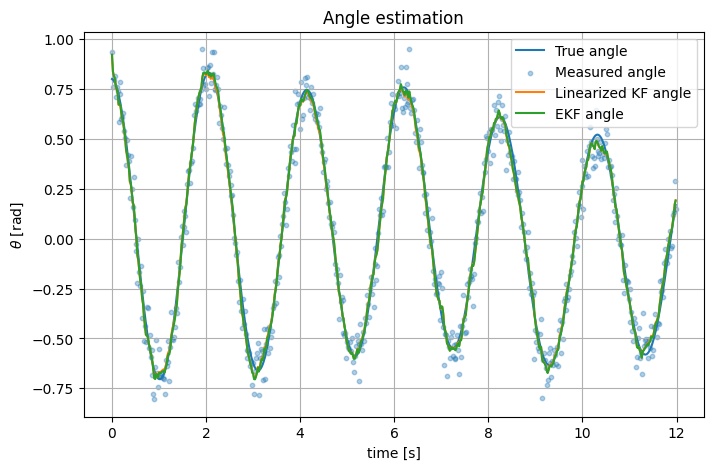

In [19]:
t = np.arange(num_steps) * dt

plt.figure(figsize=(8, 5))
plt.plot(t, true_states[:, 0], label="True angle")
plt.scatter(t, measurements[:, 0], s=10, alpha=0.35, label="Measured angle")
plt.plot(t, kf_states[:, 0], label="Linearized KF angle")
plt.plot(t, ekf_states[:, 0], label="EKF angle")
plt.xlabel("time [s]")
plt.ylabel(r"$\theta$ [rad]")
plt.title("Angle estimation")
plt.grid(True)
plt.legend()
plt.show()

## 11. Compare angular velocity trajectories

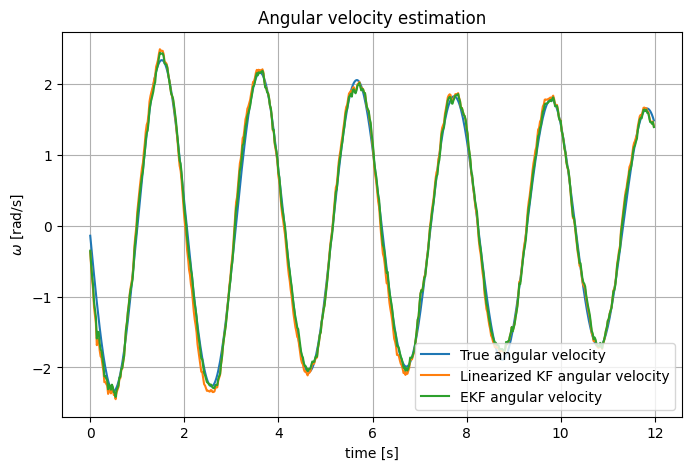

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(t, true_states[:, 1], label="True angular velocity")
plt.plot(t, kf_states[:, 1], label="Linearized KF angular velocity")
plt.plot(t, ekf_states[:, 1], label="EKF angular velocity")
plt.xlabel("time [s]")
plt.ylabel(r"$\omega$ [rad/s]")
plt.title("Angular velocity estimation")
plt.grid(True)
plt.legend()
plt.show()

## 12. Phase portrait

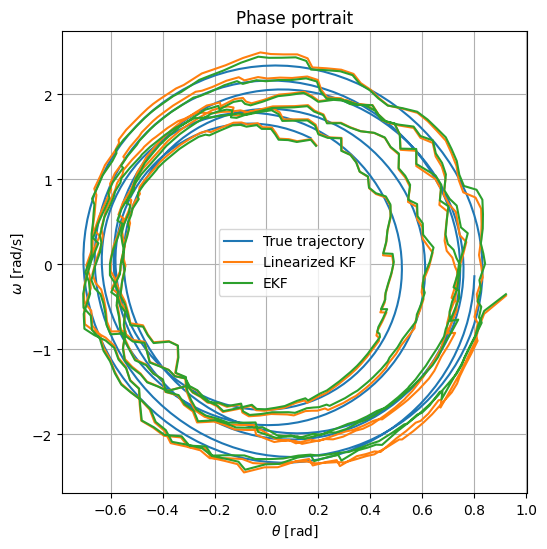

In [21]:
plt.figure(figsize=(6, 6))
plt.plot(true_states[:, 0], true_states[:, 1], label="True trajectory")
plt.plot(kf_states[:, 0], kf_states[:, 1], label="Linearized KF")
plt.plot(ekf_states[:, 0], ekf_states[:, 1], label="EKF")
plt.xlabel(r"$\theta$ [rad]")
plt.ylabel(r"$\omega$ [rad/s]")
plt.title("Phase portrait")
plt.grid(True)
plt.legend()
plt.show()

## 13. Quantitative comparison

In [22]:
kf_theta_rmse = np.sqrt(np.mean((kf_states[:, 0] - true_states[:, 0])**2))
ekf_theta_rmse = np.sqrt(np.mean((ekf_states[:, 0] - true_states[:, 0])**2))

kf_omega_rmse = np.sqrt(np.mean((kf_states[:, 1] - true_states[:, 1])**2))
ekf_omega_rmse = np.sqrt(np.mean((ekf_states[:, 1] - true_states[:, 1])**2))

print(f"Linearized KF angle RMSE:            {kf_theta_rmse:.5f} rad")
print(f"EKF angle RMSE:                      {ekf_theta_rmse:.5f} rad")
print()
print(f"Linearized KF angular velocity RMSE: {kf_omega_rmse:.5f} rad/s")
print(f"EKF angular velocity RMSE:           {ekf_omega_rmse:.5f} rad/s")

Linearized KF angle RMSE:            0.02779 rad
EKF angle RMSE:                      0.02627 rad

Linearized KF angular velocity RMSE: 0.12420 rad/s
EKF angular velocity RMSE:           0.08401 rad/s
